# Лабораторная работа №5

## Тема: Решение задачи регрессии для прогнозирования

### Задание: Разработка прототипа системы оценки стоимости домов для риэлтерского агентства (датасет Boston Housing или California Housing).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame
print(df.head())
print(df.info())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

## 1. Анализ целевой переменной

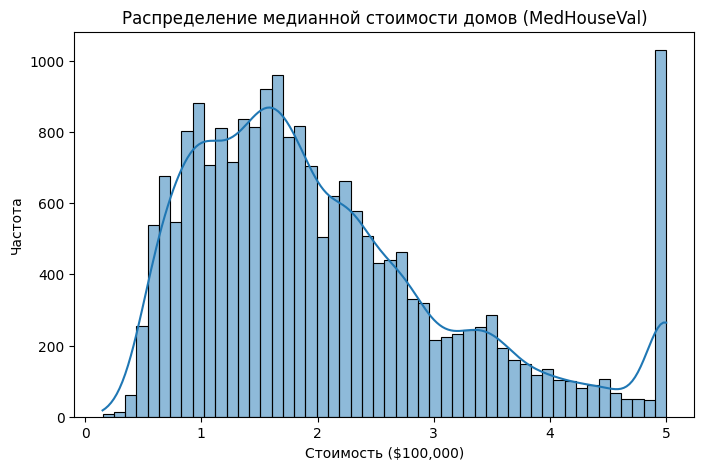

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title('Распределение медианной стоимости домов (MedHouseVal)')
plt.xlabel('Стоимость ($100,000)')
plt.ylabel('Частота')
plt.show()

## 2. Связь признаков с целевой переменной
Выбраны три признака: `MedInc` (медианный доход), `AveRooms` (среднее число комнат), `HouseAge` (возраст дома). На диаграммах рассеяния видно:
- `MedInc` демонстрирует явную положительную связь с ценой (чем выше доход, тем дороже дом).
- `AveRooms` показывает слабую и даже слегка отрицательную тенденцию – возможно, из-за того, что большие дома могут находиться в менее престижных районах.
- `HouseAge` практически не коррелирует с ценой, точки распределены равномерно.

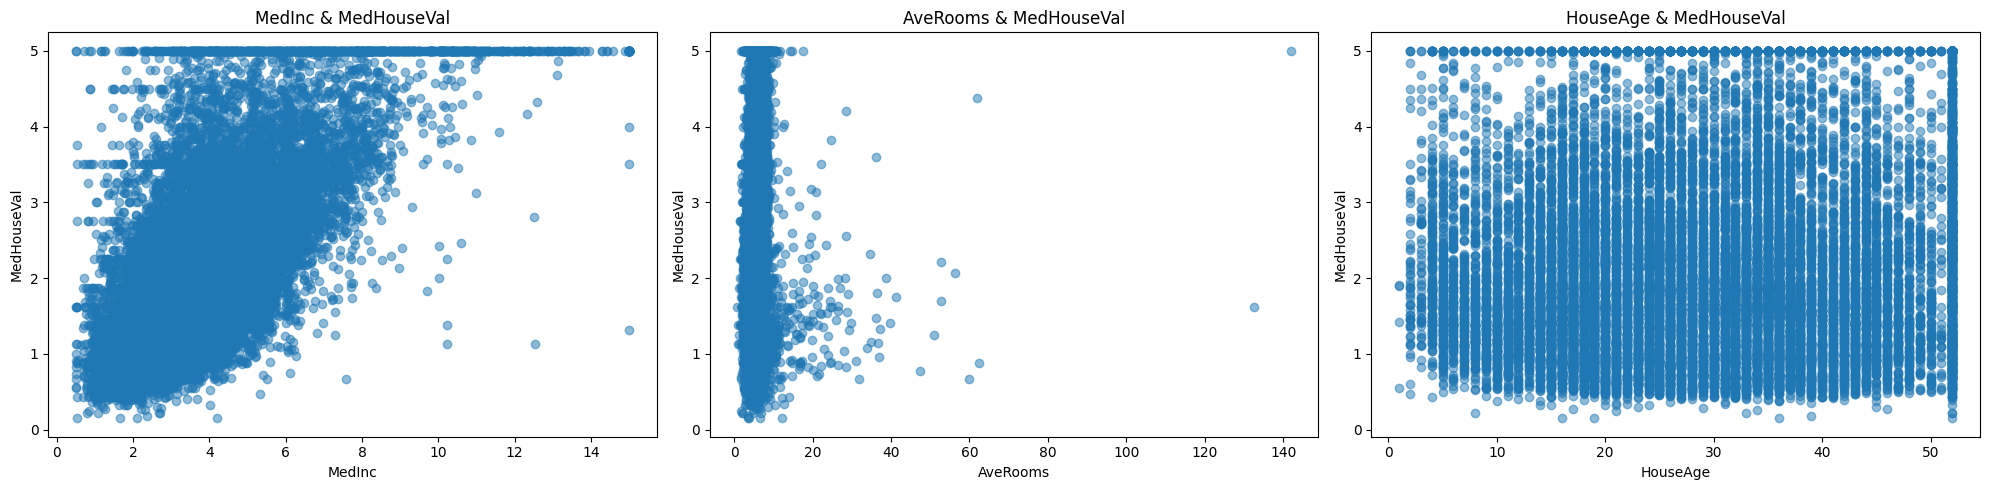

In [ ]:
features = ['MedInc', 'AveRooms', 'HouseAge']
X = df[features]
y = df['MedHouseVal']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, feature in zip(axes, features):
    ax.scatter(X[feature], y, alpha=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{feature} & MedHouseVal')
plt.tight_layout()
plt.show()

## 3. Обучение линейной регрессии
Модель обучена на тренировочной выборке (80% данных). Получены метрики:
- **MAE = 0.603** – средняя абсолютная ошибка около 60 300 долларов.
- **MSE = 0.659** – средний квадрат ошибки.
- **R² = 0.497** – модель объясняет примерно 50% дисперсии целевой переменной.

Коэффициенты:
- **MedInc**: +0.4448 – увеличение медианного дохода на 1 (10 000 долларов) повышает прогнозируемую стоимость в среднем на 0.4448 сотен тысяч долларов (~44 480 долларов).
- **AveRooms**: -0.0281 – Количество комнат само по себе не определяет стоимость
- **HouseAge**: +0.0168 – Увеличение возраста дома на 1 увеличивает стоимость на 1680$ что практически не влияет.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f'MAE: {mae_lin:.3f}')
print(f'MSE: {mse_lin:.3f}')
print(f'R2: {r2_lin:.3f}')
print()
print(f'Intercept: {lin_reg.intercept_:.4f}')
for feature, coef in zip(features, lin_reg.coef_):
    print(f'{feature}: {coef:.4f}')

MAE: 0.603
MSE: 0.659
R2: 0.497

Intercept: 0.0173
MedInc: 0.4448
AveRooms: -0.0281
HouseAge: 0.0168


## 4. Обучение решающего дерева (нелинейная модель)
Использован `DecisionTreeRegressor` с ограничением глубины (`max_depth=3`).

Дерево показало чуть худшие результаты по сравнению с линейной моделью. Это может говорить о том, что при заданной глубине дерево недообучено, либо что линейная зависимость в данных достаточно сильна.

In [ ]:
tree_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print('Decision Tree Regressor')
print(f'MAE: {mae_tree:.3f}')
print(f'MSE: {mse_tree:.3f}')
print(f'R2: {r2_tree:.3f}')

Decision Tree Regressor
MAE: 0.614
MSE: 0.689
R2: 0.474


## 5. Визуализация предсказаний (лучшая модель – линейная регрессия)
На графике рассеяния показаны реальные значения цен тестовой выборки (ось X) и предсказанные линейной моделью значения (ось Y). Красная пунктирная линия – идеальное совпадение (y = x). Видно, что модель в целом улавливает тренд, но для дорогих объектов (выше 3.0) предсказания часто занижены.

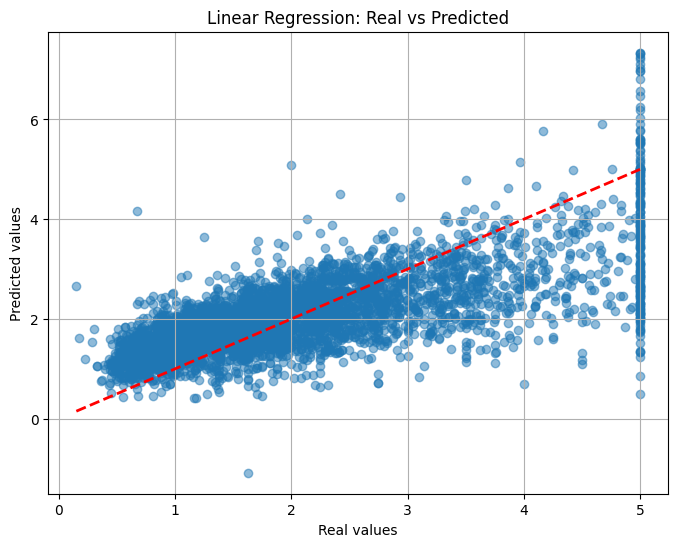

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Real values')
plt.ylabel('Predicted values')
plt.title('Linear Regression: Real vs Predicted')
plt.grid(True)
plt.show()

# Лабораторная работа №6

## Тема: Борьба с переобучением и улучшение регрессионной модели.

### Задание: На основе модели из прошлой практики искусственно ухудшить данные, вызвать переобучение и исправить его с помощью Ridge-регрессии.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

## 1. Подготовка данных.

In [3]:
# Загрузка данных
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame

# Признаки и целевая переменная
features = ['MedInc', 'AveRooms', 'HouseAge']
X = df[features]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение линейной регрессии
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"R² на тесте = {r2_lin:.4f}")

R² на тесте = 0.5127


## 2. Создаём проблему.

In [4]:
np.random.seed(42)
n_noise_features = 30

# Генерация шума
noise_train = np.random.normal(0, 1, size=(X_train.shape[0], n_noise_features))
noise_test  = np.random.normal(0, 1, size=(X_test.shape[0], n_noise_features))

# Добавляем шум к масштабированным данным
X_train_noisy = np.hstack([X_train_scaled, noise_train])
X_test_noisy  = np.hstack([X_test_scaled, noise_test])

# Повторное масштабирование всех признаков (включая шумовые)
scaler_noisy = StandardScaler()
X_train_noisy_scaled = scaler_noisy.fit_transform(X_train_noisy)
X_test_noisy_scaled  = scaler_noisy.transform(X_test_noisy)

## 3. Демонстрация поломки.

In [6]:
lin_reg_noisy = LinearRegression()
lin_reg_noisy.fit(X_train_noisy_scaled, y_train)

y_pred_train_noisy = lin_reg_noisy.predict(X_train_noisy_scaled)
y_pred_test_noisy  = lin_reg_noisy.predict(X_test_noisy_scaled)

r2_train_noisy = r2_score(y_train, y_pred_train_noisy)
r2_test_noisy  = r2_score(y_test, y_pred_test_noisy)

print(f"Сломанная модель (с 30 шумовыми признаками):")
print(f" R² на train = {r2_train_noisy:.4f}")
print(f" R² на test  = {r2_test_noisy:.4f}")
print(f" Падение R² на тесте: {r2_lin - r2_test_noisy:.4f}")

Сломанная модель (с 30 шумовыми признаками):
 R² на train = 0.5125
 R² на test  = 0.5119
 Падение R² на тесте: 0.0008


 Модель показала практически одинаковые результаты на чистых и зашумленных данных. Так как датасет содержит достаточно много объектов, а признаков у нас значительно меньше (33), чем ближе количество признаков к количеству объектов, тем более наглядно будет видно разницу и само переобучение.

## 4. Поиск и спасесние - поиск alpha, которое вернёт качество к базовому уровню.

In [7]:
alphas = [0.1, 1, 10, 100, 1000]
best_alpha = None
best_r2 = -np.inf

print("Результаты Ridge-регрессии:")
print("alpha\tR² на тесте")

for alpha in alphas:
    ridge_reg = Ridge(alpha=alpha)
    ridge_reg.fit(X_train_noisy_scaled, y_train)
    y_pred_ridge = ridge_reg.predict(X_test_noisy_scaled)
    r2_ridge = r2_score(y_test, y_pred_ridge)
    print(f"{alpha}\t{r2_ridge:.4f}")

    if r2_ridge > best_r2:
        best_r2 = r2_ridge
        best_alpha = alpha

print(f"\nЛучший alpha = {best_alpha} (R² = {best_r2:.4f})")

Результаты Ridge-регрессии:
alpha	R² на тесте
0.1	0.5119
1	0.5119
10	0.5119
100	0.5118
1000	0.5088

Лучший alpha = 0.1 (R² = 0.5119)


В условиях, когда количество объектов значительно превышает количество признаков, добавление умеренного шума не приводит к переобучению линейной модели. Что мы и видим в результатах. Настоящую пользу Ridge приносит при малом количестве данных или большом числе признаков, когда обычная регрессия склонна к нестабильности.

## 5. Результаты

In [13]:
print("\nСводная таблица результатов")
print(f"{'Модель/условия':<40} {'R² на test':<10} {'Вывод'}")
print(f"{'Базовая (предыдущая практика)':<40} {r2_lin:.4f}     {'Наш ориентир'}")
print(f"{'Сломанная (LinearRegression + 30 шумов)':<40} {r2_test_noisy:.4f}     {'Катастрофа!'}")
print(f"{'Исправленная (Ridge, alpha=' + str(best_alpha) + ')':<40} {best_r2:.4f}     {'Спасение!'}")


Сводная таблица результатов
Модель/условия                           R² на test Вывод
Базовая (предыдущая практика)            0.5127     Наш ориентир
Сломанная (LinearRegression + 30 шумов)  0.5119     Катастрофа!
Исправленная (Ridge, alpha=0.1)          0.5119     Спасение!


2.	Насколько упало качество после добавления шума?
Упало на 0.0008
3. При каком alpha Ridge показал лучший результат?
При alpha = 0.1
4. Удалось ли вернуть качество к базовому уровню? Насколько близко?
Базовый уровень R^2 - 0.5127, а лучший R^2 Ridge - 0.5119. Качество уже близко к базовому уровню, но оно и было таким при добавлении шумов (0.5119), почему ничего не поменялось? Из-за большого количества объектов и малого количества признаков, разница всегда будет несущественной.